# Lithium-Ion Battery Remaining Useful Life (RUL) Prediction
### Comprehensive 10-Model Benchmarking and 5-Fold Cross-Validation Hyperparameter Tuning

## Library Imports and Plot Configuration

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    HistGradientBoostingRegressor,
    AdaBoostRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 120

## Dataset Ingestion and Inspection

In [2]:
df = pd.read_csv("standard_scaled_dataset.csv")
df.head()

,Discharge Time (s),Decrement 3.6-3.4V (s),Max. Voltage Dischar. (V),Min. Voltage Charg. (V),Time at 4.15V (s),Time constant current (s),Charging time (s),RUL
0,-0.052560,-0.021265,-2.647285,-2.999948,0.201022,0.057978,0.032341,1112
1,0.098135,-0.019743,3.761850,-2.926318,0.206570,0.058263,0.021627,1111
2,0.097669,-0.024052,3.795231,-2.893594,0.206570,0.058263,0.018539,1110
3,0.097410,-0.026418,3.806358,-2.885413,0.205780,0.058263,0.014771,1109
4,1.901905,2.053925,4.251437,-1.470097,0.203399,1.948155,1.805569,1107


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14992 entries, 0 to 14991
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Discharge Time (s)         14992 non-null  float64
 1   Decrement 3.6-3.4V (s)     14992 non-null  float64
 2   Max. Voltage Dischar. (V)  14992 non-null  float64
 3   Min. Voltage Charg. (V)    14992 non-null  float64
 4   Time at 4.15V (s)          14992 non-null  float64
 5   Time constant current (s)  14992 non-null  float64
 6   Charging time (s)          14992 non-null  float64
 7   RUL                        14992 non-null  int64  
dtypes: float64(7), int64(1)
memory usage: 937.1 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Discharge Time (s),14992.0,4.905361e-17,1.000000,-0.133541,-0.097130,-0.085051,-0.074078,29.869077
Decrement 3.6-3.4V (s),14992.0,4.549900e-17,1.000000,-0.102379,-0.081418,-0.072779,-0.061078,29.341588
Max. Voltage Dischar. (V),14992.0,-6.331944e-16,1.000000,-9.623896,-0.688939,-0.021320,0.713060,5.063706
Min. Voltage Charg. (V),14992.0,-2.983976e-15,1.000000,-4.546160,-0.733806,-0.038419,0.697872,5.909180
Time at 4.15V (s),14992.0,4.265531e-18,1.000000,-0.415757,-0.209263,-0.085472,0.045136,27.341484
Time constant current (s),14992.0,1.753607e-17,1.000000,-0.216608,-0.112520,-0.061258,-0.012923,35.615801
Charging time (s),14992.0,7.109219e-17,1.000000,-0.383604,-0.080860,-0.062503,-0.045488,33.624655
RUL,14992.0,5.549416e+02,322.175186,0.000000,279.000000,551.000000,840.000000,1133.000000


In [5]:
pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Infinite Values": np.isinf(df.select_dtypes(include=np.number)).sum(),
    "Data Type": df.dtypes
})

,Missing Values,Infinite Values,Data Type
Discharge Time (s),0,0,float64
Decrement 3.6-3.4V (s),0,0,float64
Max. Voltage Dischar. (V),0,0,float64
Min. Voltage Charg. (V),0,0,float64
Time at 4.15V (s),0,0,float64
Time constant current (s),0,0,float64
Charging time (s),0,0,float64
RUL,0,0,int64


## Exploratory Data Analysis

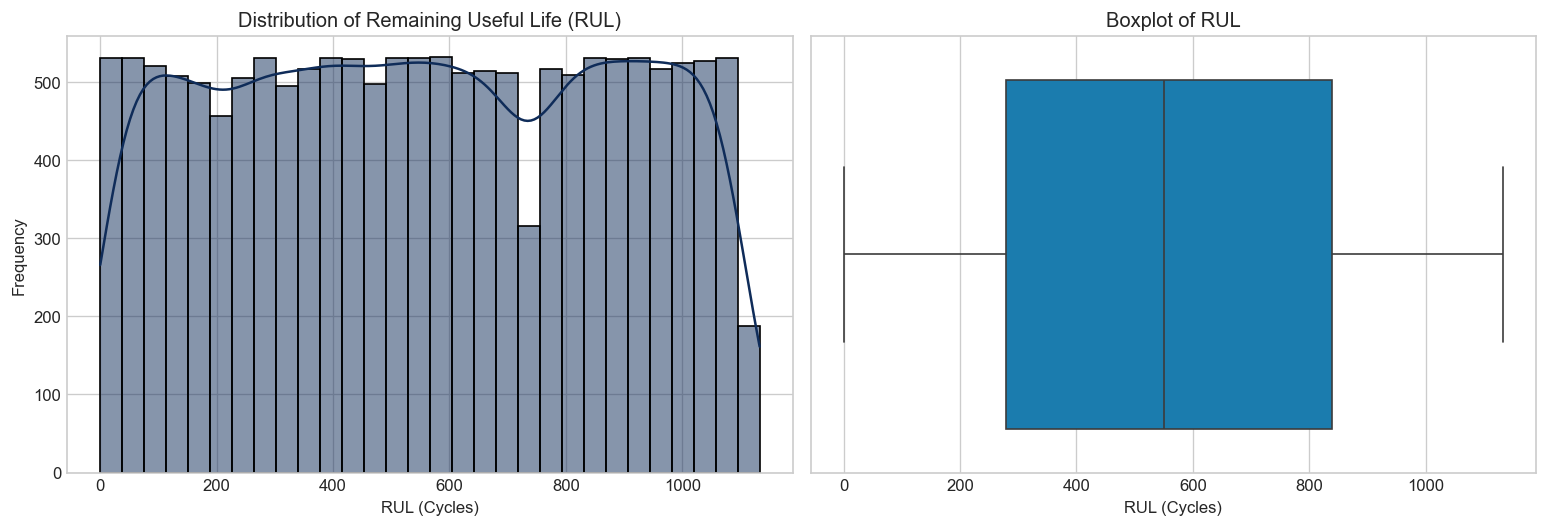

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df["RUL"], bins=30, kde=True, ax=axes[0], color="#0F2C59")
axes[0].set_title("Distribution of Remaining Useful Life (RUL)")
axes[0].set_xlabel("RUL (Cycles)")
axes[0].set_ylabel("Frequency")

sns.boxplot(x=df["RUL"], ax=axes[1], color="#0284C7")
axes[1].set_title("Boxplot of RUL")
axes[1].set_xlabel("RUL (Cycles)")

plt.tight_layout()
plt.show()

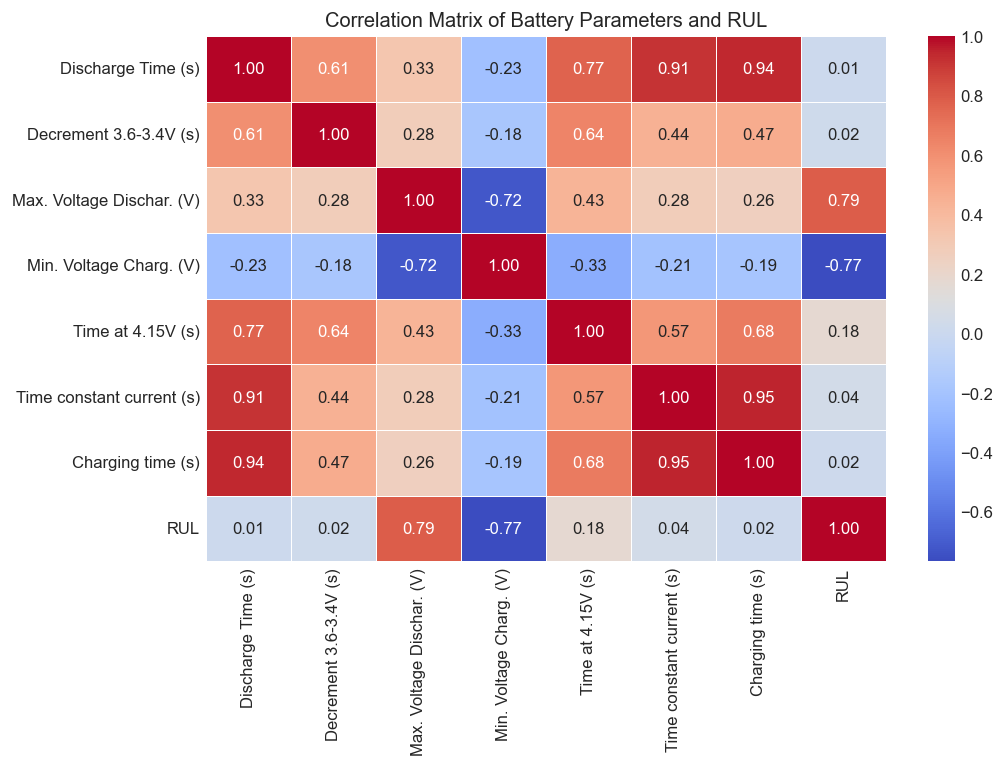

In [7]:
plt.figure(figsize=(9, 6.5))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Battery Parameters and RUL")
plt.tight_layout()
plt.show()

## Train-Test Partitioning

In [8]:
X = df.drop(columns=["RUL"])
y = df["RUL"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

## 10 Machine Learning Models Definition and 5-Fold GridSearchCV Hyperparameter Tuning

In [9]:
models_config = {
    "Extra Trees": {
        "baseline": ExtraTreesRegressor(random_state=42, n_jobs=-1),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 20],
            "model__min_samples_split": [2, 5]
        }
    },
    "Random Forest": {
        "baseline": RandomForestRegressor(random_state=42, n_jobs=-1),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 20],
            "model__min_samples_split": [2, 5]
        }
    },
    "XGBoost": {
        "baseline": XGBRegressor(objective="reg:squarederror", random_state=42, n_jobs=-1),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [4, 6]
        }
    },
    "LightGBM": {
        "baseline": LGBMRegressor(random_state=42, verbosity=-1, n_jobs=-1),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__num_leaves": [31, 63]
        }
    },
    "CatBoost": {
        "baseline": CatBoostRegressor(random_state=42, verbose=0, allow_writing_files=False),
        "param_grid": {
            "model__iterations": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__depth": [4, 6]
        }
    },
    "Hist Gradient Boosting": {
        "baseline": HistGradientBoostingRegressor(random_state=42),
        "param_grid": {
            "model__max_iter": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_leaf_nodes": [31, 63]
        }
    },
    "KNN": {
        "baseline": KNeighborsRegressor(n_jobs=-1),
        "param_grid": {
            "model__n_neighbors": [3, 5, 9],
            "model__weights": ["uniform", "distance"]
        }
    },
    "Gradient Boosting": {
        "baseline": GradientBoostingRegressor(random_state=42),
        "param_grid": {
            "model__n_estimators": [100, 200],
            "model__learning_rate": [0.05, 0.1],
            "model__max_depth": [3, 5]
        }
    },
    "AdaBoost": {
        "baseline": AdaBoostRegressor(random_state=42),
        "param_grid": {
            "model__n_estimators": [50, 100],
            "model__learning_rate": [0.05, 0.1, 0.5]
        }
    },
    "Ridge Regression": {
        "baseline": Ridge(),
        "param_grid": {
            "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0]
        }
    }
}

In [10]:
baseline_results = []
tuned_results = []
baseline_test_predictions = {}
tuned_test_predictions = {}

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for name, cfg in models_config.items():
    base_pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", cfg["baseline"])
    ])
    base_pipeline.fit(X_train, y_train)
    
    b_train_pred = base_pipeline.predict(X_train)
    b_test_pred = base_pipeline.predict(X_test)
    baseline_test_predictions[name] = b_test_pred
    
    baseline_results.append({
        "Model": name,
        "Train MAE": mean_absolute_error(y_train, b_train_pred),
        "Test MAE": mean_absolute_error(y_test, b_test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, b_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, b_test_pred)),
        "Train R2": r2_score(y_train, b_train_pred),
        "Test R2": r2_score(y_test, b_test_pred)
    })
    
    grid = GridSearchCV(
        estimator=base_pipeline,
        param_grid=cfg["param_grid"],
        cv=kf,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_
    
    t_train_pred = best_model.predict(X_train)
    t_test_pred = best_model.predict(X_test)
    tuned_test_predictions[name] = t_test_pred
    
    tuned_results.append({
        "Model": name,
        "Best Parameters": str(grid.best_params_),
        "CV Best MAE": -grid.best_score_,
        "Train MAE": mean_absolute_error(y_train, t_train_pred),
        "Test MAE": mean_absolute_error(y_test, t_test_pred),
        "Train RMSE": np.sqrt(mean_squared_error(y_train, t_train_pred)),
        "Test RMSE": np.sqrt(mean_squared_error(y_test, t_test_pred)),
        "Train R2": r2_score(y_train, t_train_pred),
        "Test R2": r2_score(y_test, t_test_pred)
    })

baseline_results_df = pd.DataFrame(baseline_results)
tuned_results_df = pd.DataFrame(tuned_results)

## Baseline vs Tuned Performance Comparison (10 Models)

In [11]:
comparison_df = pd.merge(
    baseline_results_df[["Model", "Test MAE", "Test RMSE", "Test R2"]],
    tuned_results_df[["Model", "CV Best MAE", "Test MAE", "Test RMSE", "Test R2", "Best Parameters"]],
    on="Model",
    suffixes=(" (Baseline)", " (Tuned)")
)

comparison_df["MAE Improvement (%)"] = (
    (comparison_df["Test MAE (Baseline)"] - comparison_df["Test MAE (Tuned)"])
    / comparison_df["Test MAE (Baseline)"] * 100
).round(2)

comparison_df = comparison_df.sort_values(by="Test MAE (Tuned)").reset_index(drop=True)
comparison_df

,Model,Test MAE (Baseline),Test RMSE (Baseline),Test R2 (Baseline),CV Best MAE,Test MAE (Tuned),Test RMSE (Tuned),Test R2 (Tuned),Best Parameters,MAE Improvement (%)
0,Extra Trees,7.812064,17.497125,0.996993,9.099073,7.712401,17.138314,0.997115,"{'model__max_depth': None, 'model__min_samples...",1.28
1,Random Forest,9.564478,21.240654,0.995568,10.827280,9.476490,21.208489,0.995582,"{'model__max_depth': 20, 'model__min_samples_s...",0.92
2,KNN,14.287029,30.359252,0.990946,13.103678,11.303086,26.863713,0.992911,"{'model__n_neighbors': 3, 'model__weights': 'd...",20.89
3,LightGBM,19.513659,31.341030,0.990351,13.328048,12.799805,24.563978,0.994073,"{'model__learning_rate': 0.1, 'model__n_estima...",34.41
4,Hist Gradient Boosting,19.816143,30.441963,0.990897,13.569728,13.071937,24.040016,0.994323,"{'model__learning_rate': 0.1, 'model__max_iter...",34.03
5,XGBoost,13.559671,22.353508,0.995092,15.539466,14.565846,23.911488,0.994384,"{'model__learning_rate': 0.1, 'model__max_dept...",-7.42
6,Gradient Boosting,30.433715,41.618656,0.982985,18.564477,17.938858,26.976609,0.992851,"{'model__learning_rate': 0.1, 'model__max_dept...",41.06
7,CatBoost,16.805208,25.800305,0.993461,25.642969,24.849689,34.529945,0.988288,"{'model__depth': 6, 'model__iterations': 200, ...",-47.87
8,AdaBoost,53.481859,65.812600,0.957453,54.941794,54.238415,66.810169,0.956154,"{'model__learning_rate': 0.5, 'model__n_estima...",-1.41
9,Ridge Regression,92.269447,150.924174,0.776248,92.509825,92.259223,150.937988,0.776207,{'model__alpha': 0.01},0.01


## Baseline vs Tuned Visualizations

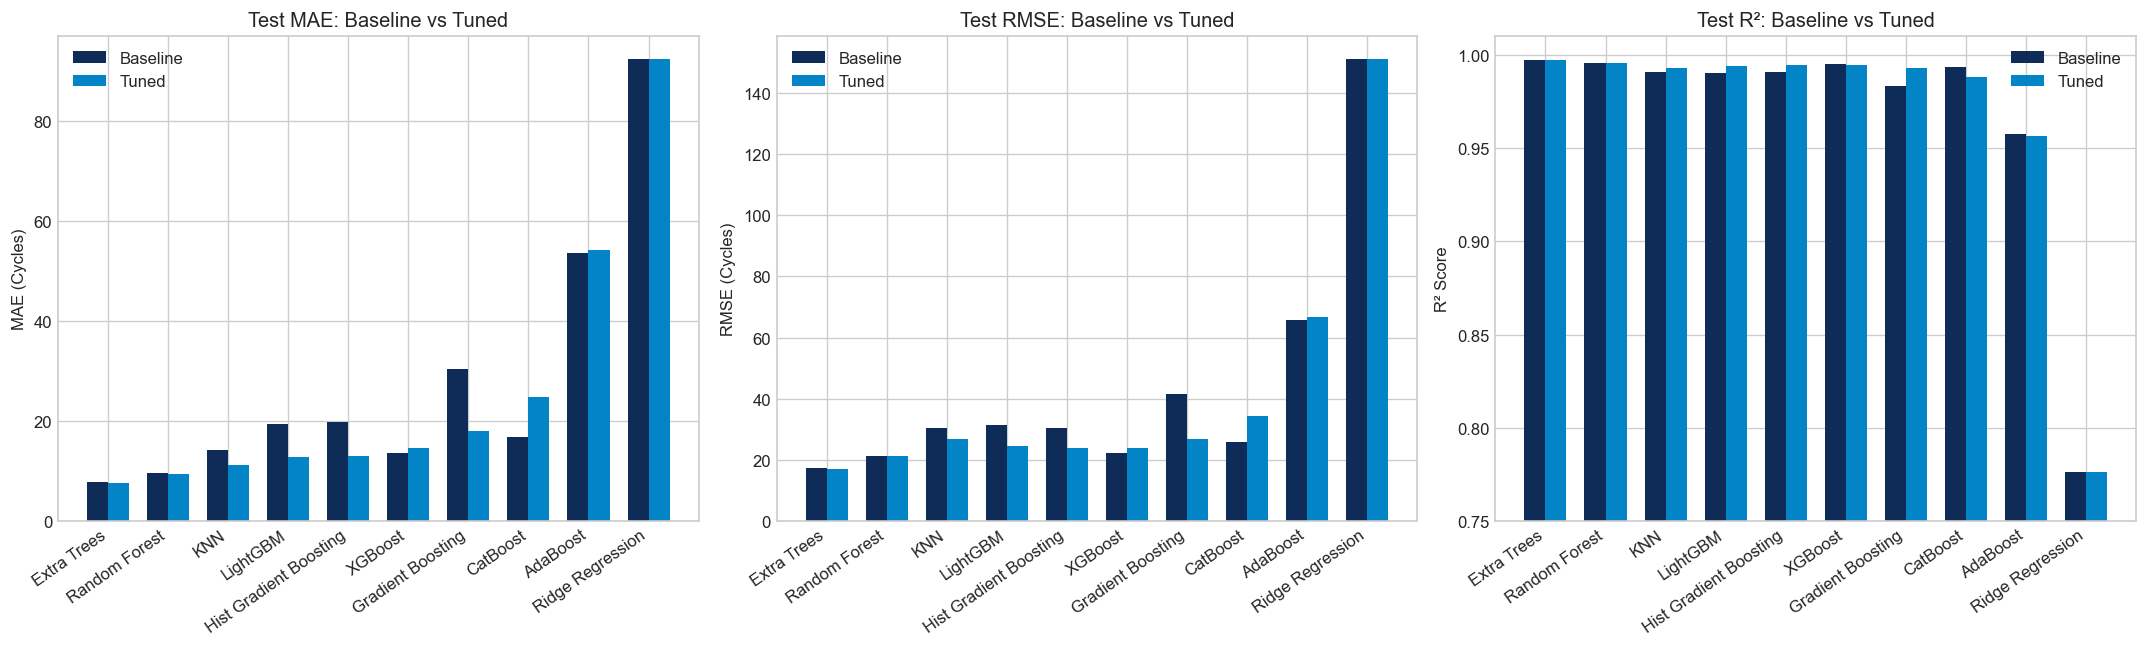

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df["Test MAE (Baseline)"], width, label="Baseline", color="#0F2C59")
axes[0].bar(x + width/2, comparison_df["Test MAE (Tuned)"], width, label="Tuned", color="#0284C7")
axes[0].set_title("Test MAE: Baseline vs Tuned")
axes[0].set_ylabel("MAE (Cycles)")
axes[0].set_xticks(x)
axes[0].set_xticklabels(comparison_df["Model"], rotation=35, ha="right")
axes[0].legend()

axes[1].bar(x - width/2, comparison_df["Test RMSE (Baseline)"], width, label="Baseline", color="#0F2C59")
axes[1].bar(x + width/2, comparison_df["Test RMSE (Tuned)"], width, label="Tuned", color="#0284C7")
axes[1].set_title("Test RMSE: Baseline vs Tuned")
axes[1].set_ylabel("RMSE (Cycles)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(comparison_df["Model"], rotation=35, ha="right")
axes[1].legend()

axes[2].bar(x - width/2, comparison_df["Test R2 (Baseline)"], width, label="Baseline", color="#0F2C59")
axes[2].bar(x + width/2, comparison_df["Test R2 (Tuned)"], width, label="Tuned", color="#0284C7")
axes[2].set_title("Test R²: Baseline vs Tuned")
axes[2].set_ylabel("R² Score")
axes[2].set_ylim(0.75, 1.01)
axes[2].set_xticks(x)
axes[2].set_xticklabels(comparison_df["Model"], rotation=35, ha="right")
axes[2].legend()

plt.tight_layout()
plt.show()

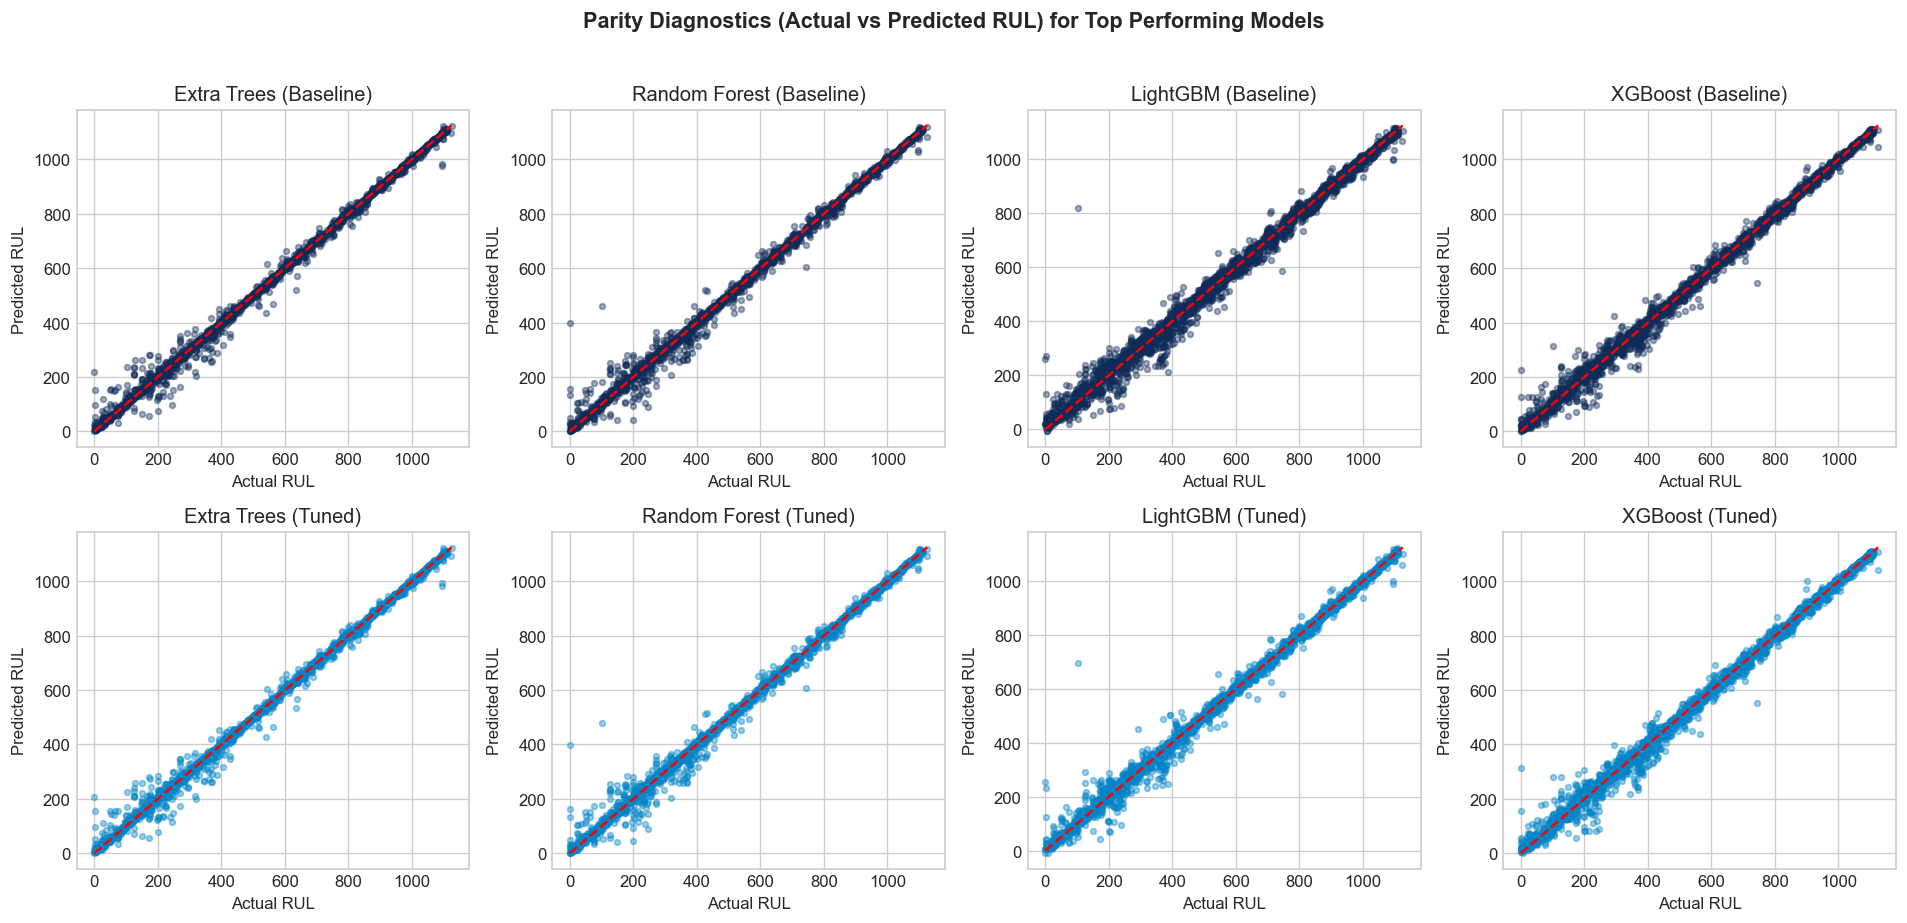

In [13]:
top_models = ["Extra Trees", "Random Forest", "LightGBM", "XGBoost"]

fig, axes = plt.subplots(2, 4, figsize=(16, 7.5))

for col_idx, name in enumerate(top_models):
    b_pred = baseline_test_predictions[name]
    t_pred = tuned_test_predictions[name]
    
    axes[0, col_idx].scatter(y_test, b_pred, alpha=0.4, s=12, color="#0F2C59")
    axes[0, col_idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=1.5)
    axes[0, col_idx].set_title(f"{name} (Baseline)")
    axes[0, col_idx].set_xlabel("Actual RUL")
    axes[0, col_idx].set_ylabel("Predicted RUL")
    
    axes[1, col_idx].scatter(y_test, t_pred, alpha=0.4, s=12, color="#0284C7")
    axes[1, col_idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", linewidth=1.5)
    axes[1, col_idx].set_title(f"{name} (Tuned)")
    axes[1, col_idx].set_xlabel("Actual RUL")
    axes[1, col_idx].set_ylabel("Predicted RUL")

plt.suptitle("Parity Diagnostics (Actual vs Predicted RUL) for Top Performing Models", y=1.02, fontsize=13, weight="bold")
plt.tight_layout()
plt.show()